# 10.2 Pandas 数据分析（约3课时）

> **学习目标：** 掌握 Pandas 的核心数据结构 Series 和 DataFrame，熟练进行数据查询、清洗、融合与分组聚合。

---

## 一、Pandas 简介

**Pandas** 是 Python 中最强大的数据分析库，构建在 NumPy 之上。

### 两大核心数据结构

| 数据结构 | 维度 | 说明 | 类比 |
|----------|------|------|------|
| **Series** | 一维 | 带标签索引的数组 | Excel 的一列 |
| **DataFrame** | 二维 | 带行标签和列标签的表格 | Excel 的工作表 |

```
DataFrame
+----------+----------+----------+
|  (index) |   Col A  |   Col B  |
+----------+----------+----------+
|  Row 0   |  value   |  value   |
|  Row 1   |  value   |  value   |
|  Row 2   |  value   |  value   |
+----------+----------+----------+
  ^ index      ^ columns
```


In [1]:
import pandas as pd
import numpy as np
print("Pandas 版本:", pd.__version__)

# Series 示例
s = pd.Series([10, 20, 30, 40], index=["a", "b", "c", "d"], name="分数")
print("Series:")
print(s)
print(f"类型: {type(s)}")
print(f"索引: {s.index.tolist()}")
print(f"值:   {s.values}")
print(f"形状: {s.shape}")


Pandas 版本: 2.0.3
Series:
a    10
b    20
c    30
d    40
Name: 分数, dtype: int64
类型: <class 'pandas.core.series.Series'>
索引: ['a', 'b', 'c', 'd']
值:   [10 20 30 40]
形状: (4,)


### Series 的常用属性和方法
```python
s.values     # 值数组
s.index      # 索引
s.dtype      # 数据类型
s.name       # 名称
s.describe() # 描述性统计
s.value_counts() # 频率统计
s.sort_values()  # 排序
s.unique()    # 唯一值
```


In [2]:
# Series 常用操作
scores = pd.Series([85, 92, 78, 95, 88, 72, 90, 85, 78, 95])
print("原始 Series:", scores.values)

print("\n描述性统计:")
print(scores.describe())

print("\n频率统计:")
print(scores.value_counts())

print("\n唯一值:", scores.unique())

print("\n排序(降序):")
print(scores.sort_values(ascending=False).values)

# Series 的向量化运算
print("\n分数/10:", (scores / 10).values)

# 条件过滤
print("\n分数 >= 90:", scores[scores >= 90].values)


原始 Series: [85 92 78 95 88 72 90 85 78 95]

描述性统计:
count    10.000000
mean     85.800000
std       7.771744
min      72.000000
25%      79.750000
50%      86.500000
75%      91.500000
max      95.000000
dtype: float64

频率统计:
85    2
78    2
95    2
92    1
88    1
72    1
90    1
Name: count, dtype: int64

唯一值: [85 92 78 95 88 72 90]

排序(降序):
[95 95 92 90 88 85 85 78 78 72]

分数/10: [8.5 9.2 7.8 9.5 8.8 7.2 9.  8.5 7.8 9.5]

分数 >= 90: [92 95 90 95]


---
## 二、DataFrame 创建

### 2.1 从字典创建
```python
df = pd.DataFrame({
    "列名1": [值列表],
    "列名2": [值列表],
})
```

### 2.2 从列表/NumPy数组创建
```python
df = pd.DataFrame(data, columns=["列名1", "列名2"])
```

### 2.3 读取外部文件
```python
pd.read_csv("文件.csv")
pd.read_excel("文件.xlsx")
pd.read_json("文件.json")
```


In [3]:
# ===== DataFrame 创建 =====

# 1. 从字典创建
df1 = pd.DataFrame({
    "姓名": ["张三", "李四", "王五", "赵六"],
    "年龄": [25, 30, 35, 28],
    "城市": ["北京", "上海", "广州", "深圳"],
    "薪资": [15000, 20000, 18000, 22000]
})
print("从字典创建:")
print(df1)
print(f"shape: {df1.shape}")

# 2. 从 NumPy 数组创建
data = np.array([
    [1, "苹果", 5.5],
    [2, "香蕉", 3.2],
    [3, "橙子", 4.8]
])
df2 = pd.DataFrame(data, columns=["编号", "水果", "单价"])
print("\n从NumPy创建:")
print(df2)

# 3. 从列表的字典创建（更灵活）
records = [
    {"学科": "数学", "成绩": 95, "班级": "A"},
    {"学科": "语文", "成绩": 88, "班级": "A"},
    {"学科": "英语", "成绩": 92, "班级": "B"},
    {"学科": "物理", "成绩": 78, "班级": "B"},
]
df3 = pd.DataFrame(records)
print("\n从记录列表创建:")
print(df3)


从字典创建:
   姓名  年龄  城市     薪资
0  张三  25  北京  15000
1  李四  30  上海  20000
2  王五  35  广州  18000
3  赵六  28  深圳  22000
shape: (4, 4)

从NumPy创建:
  编号  水果   单价
0  1  苹果  5.5
1  2  香蕉  3.2
2  3  橙子  4.8

从记录列表创建:
   学科  成绩 班级
0  数学  95  A
1  语文  88  A
2  英语  92  B
3  物理  78  B


### 2.4 读取 CSV 文件

Pandas 最常用的数据读取方式。我们使用内置方式创建示例 CSV 来演示。

In [4]:
# ===== 读取 CSV =====
# 先创建一个示例 CSV 文件
csv_content = """姓名,年龄,城市,薪资,部门
张三,25,北京,15000,技术部
李四,30,上海,20000,市场部
王五,35,广州,18000,技术部
赵六,28,深圳,22000,市场部
孙七,32,北京,25000,技术部
周八,27,上海,16000,设计部
吴九,29,广州,19000,设计部
郑十,31,深圳,21000,技术部"""

with open("employee_data.csv", "w", encoding="utf-8") as f:
    f.write(csv_content)

# 读取 CSV
df = pd.read_csv("employee_data.csv")
print(df)
print(f"\nshape: {df.shape}")
print(f"dtypes:\n{df.dtypes}")


   姓名  年龄  城市     薪资   部门
0  张三  25  北京  15000  技术部
1  李四  30  上海  20000  市场部
2  王五  35  广州  18000  技术部
3  赵六  28  深圳  22000  市场部
4  孙七  32  北京  25000  技术部
5  周八  27  上海  16000  设计部
6  吴九  29  广州  19000  设计部
7  郑十  31  深圳  21000  技术部

shape: (8, 5)
dtypes:
姓名    object
年龄     int64
城市    object
薪资     int64
部门    object
dtype: object


---
## 三、基本操作：数据概览

| 方法 | 说明 |
|------|------|
| `df.head(n)` | 查看前 n 行（默认5） |
| `df.tail(n)` | 查看末尾 n 行 |
| `df.info()` | 数据类型、非空数量、内存 |
| `df.describe()` | 数值列的描述性统计 |
| `df.dtypes` | 各列数据类型 |
| `df.columns` | 列名列表 |
| `df.index` | 行索引 |
| `df.shape` | 形状 (行数, 列数) |
| `df.values` | 底层 NumPy 数组 |
| `df.memory_usage()` | 内存使用情况 |


In [5]:
# ===== 基本操作 =====
df = pd.read_csv("employee_data.csv")

print("===== head(3) =====")
print(df.head(3))

print("\n===== tail(2) =====")
print(df.tail(2))

print("\n===== dtypes =====")
print(df.dtypes)

print("\n===== columns =====")
print(df.columns.tolist())

print("\n===== index =====")
print(df.index.tolist())

print("\n===== shape =====")
print(df.shape)

print("\n===== info() =====")
df.info()


===== head(3) =====
   姓名  年龄  城市     薪资   部门
0  张三  25  北京  15000  技术部
1  李四  30  上海  20000  市场部
2  王五  35  广州  18000  技术部

===== tail(2) =====
   姓名  年龄  城市     薪资   部门
6  吴九  29  广州  19000  设计部
7  郑十  31  深圳  21000  技术部

===== dtypes =====
姓名    object
年龄     int64
城市    object
薪资     int64
部门    object
dtype: object

===== columns =====
['姓名', '年龄', '城市', '薪资', '部门']

===== index =====
[0, 1, 2, 3, 4, 5, 6, 7]

===== shape =====
(8, 5)

===== info() =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   姓名      8 non-null      object
 1   年龄      8 non-null      int64 
 2   城市      8 non-null      object
 3   薪资      8 non-null      int64 
 4   部门      8 non-null      object
dtypes: int64(2), object(3)
memory usage: 452.0+ bytes


In [6]:
# ===== describe() =====
print("数值列描述性统计:")
print(df.describe())

# describe(include='all') 包含所有列
print("\n所有列描述性统计:")
print(df.describe(include='all'))


数值列描述性统计:
              年龄            薪资
count   8.000000      8.000000
mean   29.625000  19500.000000
std     3.113909   3251.373336
min    25.000000  15000.000000
25%    27.750000  17500.000000
50%    29.500000  19500.000000
75%    31.250000  21250.000000
max    35.000000  25000.000000

所有列描述性统计:
         姓名         年龄   城市            薪资   部门
count     8   8.000000    8      8.000000    8
unique    8        NaN    4           NaN    3
top      张三        NaN   北京           NaN  技术部
freq      1        NaN    2           NaN    4
mean    NaN  29.625000  NaN  19500.000000  NaN
std     NaN   3.113909  NaN   3251.373336  NaN
min     NaN  25.000000  NaN  15000.000000  NaN
25%     NaN  27.750000  NaN  17500.000000  NaN
50%     NaN  29.500000  NaN  19500.000000  NaN
75%     NaN  31.250000  NaN  21250.000000  NaN
max     NaN  35.000000  NaN  25000.000000  NaN


---
## 四、数据查询与索引

### 4.1 loc —— 标签索引
使用**行标签**和**列名**进行定位：
```python
df.loc[行标签, 列名]
df.loc["张三"]          # 某一行
df.loc[:, "薪资"]       # 某一列
df.loc[0:2, ["姓名", "薪资"]]  # 切片（包含末尾）
df.loc[df["年龄"] > 28]       # 布尔过滤
```

### 4.2 iloc —— 位置索引
使用**整数位置**（从0开始）：
```python
df.iloc[0]              # 第0行
df.iloc[:, 1]           # 第1列
df.iloc[0:3, 0:2]       # 切片（不包含末尾）
```


In [7]:
# ===== loc 标签索引 =====
df = pd.read_csv("employee_data.csv")

# 设置姓名为索引
df_idx = df.set_index("姓名")
print("设置索引后:")
print(df_idx)

print("\n--- loc 查询 ---")
print("某一行 (张三):")
print(df_idx.loc["张三"])

print("\n某一列 (薪资):")
print(df_idx.loc[:, "薪资"])

print("\n多行多列:")
print(df_idx.loc[["张三", "赵六"], ["年龄", "薪资", "部门"]])

print("\nloc 切片 (包含末尾):")
print(df_idx.loc["张三":"王五", "年龄":"薪资"])

print("\n布尔过滤 (年龄>28):")
print(df_idx.loc[df_idx["年龄"] > 28])

print("\n组合条件:")
mask = (df_idx["年龄"] > 28) & (df_idx["薪资"] > 20000)
print(df_idx.loc[mask])


设置索引后:
    年龄  城市     薪资   部门
姓名                    
张三  25  北京  15000  技术部
李四  30  上海  20000  市场部
王五  35  广州  18000  技术部
赵六  28  深圳  22000  市场部
孙七  32  北京  25000  技术部
周八  27  上海  16000  设计部
吴九  29  广州  19000  设计部
郑十  31  深圳  21000  技术部

--- loc 查询 ---
某一行 (张三):
年龄       25
城市       北京
薪资    15000
部门      技术部
Name: 张三, dtype: object

某一列 (薪资):
姓名
张三    15000
李四    20000
王五    18000
赵六    22000
孙七    25000
周八    16000
吴九    19000
郑十    21000
Name: 薪资, dtype: int64

多行多列:
    年龄     薪资   部门
姓名                
张三  25  15000  技术部
赵六  28  22000  市场部

loc 切片 (包含末尾):
    年龄  城市     薪资
姓名               
张三  25  北京  15000
李四  30  上海  20000
王五  35  广州  18000

布尔过滤 (年龄>28):
    年龄  城市     薪资   部门
姓名                    
李四  30  上海  20000  市场部
王五  35  广州  18000  技术部
孙七  32  北京  25000  技术部
吴九  29  广州  19000  设计部
郑十  31  深圳  21000  技术部

组合条件:
    年龄  城市     薪资   部门
姓名                    
孙七  32  北京  25000  技术部
郑十  31  深圳  21000  技术部


In [8]:
# ===== iloc 位置索引 =====
print("第0行:")
print(df.iloc[0])

print("\n第1到3行，第0到2列:")
print(df.iloc[1:4, 0:3])

print("\n最后一行:")
print(df.iloc[-1])

print("\n所有行，特定列 (0, 2, 4):")
print(df.iloc[:, [0, 2, 4]])


第0行:
姓名       张三
年龄       25
城市       北京
薪资    15000
部门      技术部
Name: 0, dtype: object

第1到3行，第0到2列:
   姓名  年龄  城市
1  李四  30  上海
2  王五  35  广州
3  赵六  28  深圳

最后一行:
姓名       郑十
年龄       31
城市       深圳
薪资    21000
部门      技术部
Name: 7, dtype: object

所有行，特定列 (0, 2, 4):
   姓名  城市   部门
0  张三  北京  技术部
1  李四  上海  市场部
2  王五  广州  技术部
3  赵六  深圳  市场部
4  孙七  北京  技术部
5  周八  上海  设计部
6  吴九  广州  设计部
7  郑十  深圳  技术部


### 4.3 列选择与条件过滤

```python
# 选择单列 -> 返回 Series
df["列名"]

# 选择多列 -> 返回 DataFrame
df[["列名1", "列名2"]]

# 条件过滤
df[df["列名"] > 值]

# query() 方法（更简洁）
df.query("年龄 > 28 and 薪资 > 20000")
```


In [9]:
# ===== 列选择与条件过滤 =====
df = pd.read_csv("employee_data.csv")

# 单列选择
print("选择'姓名'列 (Series):")
print(df["姓名"].values)

# 多列选择
print("\n选择多列 (DataFrame):")
print(df[["姓名", "城市", "薪资"]])

# 条件过滤
print("\n薪资 > 18000 的员工:")
print(df[df["薪资"] > 18000])

# 多条件
print("\n技术部 & 薪资>15000:")
print(df[(df["部门"] == "技术部") & (df["薪资"] > 15000)])

# query() 方法
print("\nquery() 查询:")
result = df.query("年龄 > 28 and 薪资 > 20000")
print(result)

# isin() 方法
print("\n城市为北京或深圳:")
print(df[df["城市"].isin(["北京", "深圳"])])

# between() 方法
print("\n年龄在27-31之间:")
print(df[df["年龄"].between(27, 31)])


选择'姓名'列 (Series):
['张三' '李四' '王五' '赵六' '孙七' '周八' '吴九' '郑十']

选择多列 (DataFrame):
   姓名  城市     薪资
0  张三  北京  15000
1  李四  上海  20000
2  王五  广州  18000
3  赵六  深圳  22000
4  孙七  北京  25000
5  周八  上海  16000
6  吴九  广州  19000
7  郑十  深圳  21000

薪资 > 18000 的员工:
   姓名  年龄  城市     薪资   部门
1  李四  30  上海  20000  市场部
3  赵六  28  深圳  22000  市场部
4  孙七  32  北京  25000  技术部
6  吴九  29  广州  19000  设计部
7  郑十  31  深圳  21000  技术部

技术部 & 薪资>15000:
   姓名  年龄  城市     薪资   部门
2  王五  35  广州  18000  技术部
4  孙七  32  北京  25000  技术部
7  郑十  31  深圳  21000  技术部

query() 查询:
   姓名  年龄  城市     薪资   部门
4  孙七  32  北京  25000  技术部
7  郑十  31  深圳  21000  技术部

城市为北京或深圳:
   姓名  年龄  城市     薪资   部门
0  张三  25  北京  15000  技术部
3  赵六  28  深圳  22000  市场部
4  孙七  32  北京  25000  技术部
7  郑十  31  深圳  21000  技术部

年龄在27-31之间:
   姓名  年龄  城市     薪资   部门
1  李四  30  上海  20000  市场部
3  赵六  28  深圳  22000  市场部
5  周八  27  上海  16000  设计部
6  吴九  29  广州  19000  设计部
7  郑十  31  深圳  21000  技术部


---
## 五、数据融合

### 5.1 merge（合并）—— 类似 SQL JOIN

```python
pd.merge(left, right, on="键列", how="inner|left|right|outer")
```

| 合并方式 | 说明 |
|----------|------|
| `inner`（默认） | 只保留两表都有的键 |
| `left` | 保留左表所有行，右表无匹配则为NaN |
| `right` | 保留右表所有行 |
| `outer` | 保留所有行 |

### 5.2 concat（拼接）

```python
pd.concat([df1, df2], axis=0)  # 垂直拼接（默认）
pd.concat([df1, df2], axis=1)  # 水平拼接
```

### 5.3 join（连接）
基于索引的合并：
```python
df1.join(df2, on="键列", how="left")
```


In [10]:
# ===== 数据融合演示 =====

# 5.1 merge
employees = pd.DataFrame({
    "工号": [1001, 1002, 1003, 1004, 1005],
    "姓名": ["张三", "李四", "王五", "赵六", "孙七"],
    "部门ID": ["D01", "D02", "D01", "D03", "D02"]
})

departments = pd.DataFrame({
    "部门ID": ["D01", "D02", "D03", "D04"],
    "部门名称": ["技术部", "市场部", "设计部", "财务部"],
    "部门预算": [500000, 300000, 200000, 400000]
})

print("员工表:")
print(employees)
print("\n部门表:")
print(departments)

# inner join
print("\n--- inner join ---")
print(pd.merge(employees, departments, on="部门ID", how="inner"))

# left join
print("\n--- left join ---")
print(pd.merge(employees, departments, on="部门ID", how="left"))

# outer join
print("\n--- outer join ---")
print(pd.merge(employees, departments, on="部门ID", how="outer"))

# 5.2 concat
print("\n--- concat 垂直拼接 ---")
df_a = pd.DataFrame({"姓名": ["张三", "李四"], "成绩": [85, 90]})
df_b = pd.DataFrame({"姓名": ["王五", "赵六"], "成绩": [78, 92]})
print(pd.concat([df_a, df_b], ignore_index=True))

print("\n--- concat 水平拼接 ---")
df_c = pd.DataFrame({"年龄": [25, 30]})
df_d = pd.DataFrame({"城市": ["北京", "上海"]})
print(pd.concat([df_a[["姓名"]], df_c, df_d], axis=1))


员工表:
     工号  姓名 部门ID
0  1001  张三  D01
1  1002  李四  D02
2  1003  王五  D01
3  1004  赵六  D03
4  1005  孙七  D02

部门表:
  部门ID 部门名称    部门预算
0  D01  技术部  500000
1  D02  市场部  300000
2  D03  设计部  200000
3  D04  财务部  400000

--- inner join ---
     工号  姓名 部门ID 部门名称    部门预算
0  1001  张三  D01  技术部  500000
1  1003  王五  D01  技术部  500000
2  1002  李四  D02  市场部  300000
3  1005  孙七  D02  市场部  300000
4  1004  赵六  D03  设计部  200000

--- left join ---
     工号  姓名 部门ID 部门名称    部门预算
0  1001  张三  D01  技术部  500000
1  1002  李四  D02  市场部  300000
2  1003  王五  D01  技术部  500000
3  1004  赵六  D03  设计部  200000
4  1005  孙七  D02  市场部  300000

--- outer join ---
       工号   姓名 部门ID 部门名称    部门预算
0  1001.0   张三  D01  技术部  500000
1  1003.0   王五  D01  技术部  500000
2  1002.0   李四  D02  市场部  300000
3  1005.0   孙七  D02  市场部  300000
4  1004.0   赵六  D03  设计部  200000
5     NaN  NaN  D04  财务部  400000

--- concat 垂直拼接 ---
   姓名  成绩
0  张三  85
1  李四  90
2  王五  78
3  赵六  92

--- concat 水平拼接 ---
   姓名  年龄  城市
0  张三  25  北京
1  李四  30  上海


---
## 六、缺失值处理

缺失值是数据分析中的常见问题。Pandas 使用 `NaN`（Not a Number）表示缺失值。

| 方法 | 说明 |
|------|------|
| `df.isna()` / `df.isnull()` | 检测缺失值 -> 布尔表 |
| `df.isna().sum()` | 每列缺失值计数 |
| `df.fillna(value)` | 用指定值填充 |
| `df.dropna()` | 删除含缺失值的行 |
| `df.interpolate()` | 线性插值填充 |

### 填充策略
- **常数填充**：`fillna(0)`, `fillna("未知")`
- **统计量填充**：`fillna(df.mean())`, `fillna(df.median())`
- **前向/后向填充**：`fillna(method="ffill")`, `fillna(method="bfill")`
- **插值填充**：`interpolate(method="linear")`


In [11]:
# ===== 缺失值处理 =====
# 创建含缺失值的数据
data_missing = pd.DataFrame({
    "姓名": ["张三", "李四", "王五", "赵六", None],
    "年龄": [25, None, 35, 28, 32],
    "薪资": [15000, 20000, None, 22000, 25000],
    "城市": ["北京", "上海", "广州", None, "北京"]
})
print("含缺失值的数据:")
print(data_missing)

# 1. 检测缺失值
print("\n--- isna() ---")
print(data_missing.isna())
print("\n每列缺失值数量:")
print(data_missing.isna().sum())

# 2. 删除缺失值
print("\n--- dropna() 删除含缺失值的行 ---")
print(data_missing.dropna())

print("\n--- dropna(subset=['姓名']) 只检查姓名列 ---")
print(data_missing.dropna(subset=["姓名"]))

# 3. 填充缺失值
print("\n--- fillna(0) 用0填充 ---")
print(data_missing.fillna(0))

print("\n--- fillna(均值) 数值列用均值填充 ---")
df_filled = data_missing.copy()
df_filled["年龄"] = df_filled["年龄"].fillna(df_filled["年龄"].mean())
df_filled["薪资"] = df_filled["薪资"].fillna(df_filled["薪资"].median())
df_filled["城市"] = df_filled["城市"].fillna("未知")
df_filled["姓名"] = df_filled["姓名"].fillna("匿名")
print(df_filled)

# 4. 插值填充
print("\n--- interpolate() 插值 ---")
time_series = pd.DataFrame({
    "日期": pd.date_range("2024-01-01", periods=10),
    "温度": [5, np.nan, 7, np.nan, np.nan, 10, 12, np.nan, 8, 6]
})
print("原始:")
print(time_series)
print("\n线性插值后:")
time_series["温度_插值"] = time_series["温度"].interpolate(method="linear")
print(time_series[["日期", "温度", "温度_插值"]])


含缺失值的数据:
     姓名    年龄       薪资    城市
0    张三  25.0  15000.0    北京
1    李四   NaN  20000.0    上海
2    王五  35.0      NaN    广州
3    赵六  28.0  22000.0  None
4  None  32.0  25000.0    北京

--- isna() ---
      姓名     年龄     薪资     城市
0  False  False  False  False
1  False   True  False  False
2  False  False   True  False
3  False  False  False   True
4   True  False  False  False

每列缺失值数量:
姓名    1
年龄    1
薪资    1
城市    1
dtype: int64

--- dropna() 删除含缺失值的行 ---
   姓名    年龄       薪资  城市
0  张三  25.0  15000.0  北京

--- dropna(subset=['姓名']) 只检查姓名列 ---
   姓名    年龄       薪资    城市
0  张三  25.0  15000.0    北京
1  李四   NaN  20000.0    上海
2  王五  35.0      NaN    广州
3  赵六  28.0  22000.0  None

--- fillna(0) 用0填充 ---
   姓名    年龄       薪资  城市
0  张三  25.0  15000.0  北京
1  李四   0.0  20000.0  上海
2  王五  35.0      0.0  广州
3  赵六  28.0  22000.0   0
4   0  32.0  25000.0  北京

--- fillna(均值) 数值列用均值填充 ---
   姓名    年龄       薪资  城市
0  张三  25.0  15000.0  北京
1  李四  30.0  20000.0  上海
2  王五  35.0  21000.0  广州
3  赵六  28.0  

---
## 七、数据分组与聚合

`groupby()` 是 Pandas 最强大的功能之一，类似于 SQL 的 `GROUP BY`。

```python
df.groupby("分组列").agg({
    "数值列": ["mean", "sum", "count"]
})
```

### 常用聚合函数
| 函数 | 说明 |
|------|------|
| `mean()` | 均值 |
| `sum()` | 求和 |
| `count()` | 计数 |
| `min()` / `max()` | 最小/最大值 |
| `std()` | 标准差 |
| `median()` | 中位数 |
| `first()` / `last()` | 第一个/最后一个 |
| `nunique()` | 唯一值计数 |
| `agg()` | 自定义聚合 |


In [12]:
# ===== 分组与聚合 =====
df = pd.read_csv("employee_data.csv")
print("原始数据:")
print(df)

# 1. 基本分组
print("\n--- 按部门分组统计 ---")
dept_stats = df.groupby("部门").agg({
    "年龄": ["mean", "count"],
    "薪资": ["mean", "sum", "max", "min"]
}).round(1)
print(dept_stats)

# 2. 按城市分组
print("\n--- 按城市分组 ---")
city_stats = df.groupby("城市").agg(
    员工数=("姓名", "count"),
    平均薪资=("薪资", "mean"),
    平均年龄=("年龄", "mean")
).round(1)
print(city_stats)

# 3. 多重分组
print("\n--- 按城市+部门分组 ---")
multi = df.groupby(["城市", "部门"]).agg(
    人数=("姓名", "count"),
    平均薪资=("薪资", "mean")
).round(1)
print(multi)

# 4. transform() -- 与原表同形状的聚合结果
print("\n--- transform: 每人薪资与部门平均薪资的差 ---")
df["部门平均薪资"] = df.groupby("部门")["薪资"].transform("mean")
df["薪资偏差"] = df["薪资"] - df["部门平均薪资"]
print(df[["姓名", "部门", "薪资", "部门平均薪资", "薪资偏差"]])

# 5. 自定义聚合
print("\n--- 自定义聚合函数 ---")
def salary_range(x):
    return x.max() - x.min()

custom = df.groupby("部门").agg(
    人数=("姓名", "count"),
    薪资范围=("薪资", salary_range),
    薪资标准差=("薪资", "std")
).round(2)
print(custom)


原始数据:
   姓名  年龄  城市     薪资   部门
0  张三  25  北京  15000  技术部
1  李四  30  上海  20000  市场部
2  王五  35  广州  18000  技术部
3  赵六  28  深圳  22000  市场部
4  孙七  32  北京  25000  技术部
5  周八  27  上海  16000  设计部
6  吴九  29  广州  19000  设计部
7  郑十  31  深圳  21000  技术部

--- 按部门分组统计 ---
       年龄             薪资                     
     mean count     mean    sum    max    min
部门                                           
市场部  29.0     2  21000.0  42000  22000  20000
技术部  30.8     4  19750.0  79000  25000  15000
设计部  28.0     2  17500.0  35000  19000  16000

--- 按城市分组 ---
    员工数     平均薪资  平均年龄
城市                    
上海    2  18000.0  28.5
北京    2  20000.0  28.5
广州    2  18500.0  32.0
深圳    2  21500.0  29.5

--- 按城市+部门分组 ---
        人数     平均薪资
城市 部门              
上海 市场部   1  20000.0
   设计部   1  16000.0
北京 技术部   2  20000.0
广州 技术部   1  18000.0
   设计部   1  19000.0
深圳 市场部   1  22000.0
   技术部   1  21000.0

--- transform: 每人薪资与部门平均薪资的差 ---
   姓名   部门     薪资   部门平均薪资    薪资偏差
0  张三  技术部  15000  19750.0 -4750.0
1  李四  市场部  

---
## 八、综合实践：Titanic 数据集分析

使用 Pandas 对经典 Titanic 数据集进行完整的分析流程。


In [13]:
# ===== Titanic 数据集分析 =====

# 创建模拟的 Titanic 数据集（包含缺失值，以便演示数据清洗）
titanic_data = {
    "PassengerId": list(range(1, 16)),
    "Name": [
        "Braund, Mr. Owen", "Cumings, Mrs. John", "Heikkinen, Miss. Laina",
        "Futrelle, Mrs. Jacques", "Allen, Mr. William", "Moran, Mr. James",
        "McCarthy, Mr. Timothy", "Palsson, Master. Gosta", "Johnson, Mrs. Oscar",
        "Nasser, Mrs. Nicholas", "Sandstrom, Miss. Marguerite", "Bonnell, Miss. Elizabeth",
        "Saundercock, Mr. William", "Andersson, Mr. Anders", None
    ],
    "Sex": ["male", "female", "female", "female", "male", "male", "male",
            "male", "female", "female", "female", "female", "male", "male", "male"],
    "Age": [22, 38, 26, 35, 35, None, 54, 4, 27, 14, 4, 58, 20, 39, None],
    "Survived": [0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0],
    "Pclass": [3, 1, 3, 1, 3, 3, 1, 3, 2, 2, 3, 1, 3, 2, 3],
    "Fare": [7.25, 71.28, 7.92, 53.10, 8.05, 8.46, 51.86, 8.73, 26.0, 30.07,
            16.70, 27.72, 8.05, 9.48, None],
    "Embarked": ["S", "C", "S", "S", "S", None, "S", "S", "S", "C",
                 "S", "S", "S", "S", "Q"]
}

df = pd.DataFrame(titanic_data)
print("Titanic 数据集 (前10行):")
print(df.head(10))
print(f"\n总样本数: {len(df)}")


Titanic 数据集 (前10行):
   PassengerId                    Name     Sex   Age  Survived  Pclass   Fare  \
0            1        Braund, Mr. Owen    male  22.0         0       3   7.25   
1            2      Cumings, Mrs. John  female  38.0         1       1  71.28   
2            3  Heikkinen, Miss. Laina  female  26.0         1       3   7.92   
3            4  Futrelle, Mrs. Jacques  female  35.0         1       1  53.10   
4            5      Allen, Mr. William    male  35.0         0       3   8.05   
5            6        Moran, Mr. James    male   NaN         0       3   8.46   
6            7   McCarthy, Mr. Timothy    male  54.0         0       1  51.86   
7            8  Palsson, Master. Gosta    male   4.0         0       3   8.73   
8            9     Johnson, Mrs. Oscar  female  27.0         1       2  26.00   
9           10   Nasser, Mrs. Nicholas  female  14.0         1       2  30.07   

  Embarked  
0        S  
1        C  
2        S  
3        S  
4        S  
5     None

In [14]:
# ===== 第1步：数据概览 =====
print("=" * 50)
print("第1步：数据概览")
print("=" * 50)

print("\n--- info() ---")
df.info()

print("\n--- 缺失值统计 ---")
print(df.isna().sum())

print("\n--- 数值列描述性统计 ---")
print(df.describe())


第1步：数据概览

--- info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  15 non-null     int64  
 1   Name         14 non-null     object 
 2   Sex          15 non-null     object 
 3   Age          13 non-null     float64
 4   Survived     15 non-null     int64  
 5   Pclass       15 non-null     int64  
 6   Fare         14 non-null     float64
 7   Embarked     14 non-null     object 
dtypes: float64(2), int64(3), object(3)
memory usage: 1.1+ KB

--- 缺失值统计 ---
PassengerId    0
Name           1
Sex            0
Age            2
Survived       0
Pclass         0
Fare           1
Embarked       1
dtype: int64

--- 数值列描述性统计 ---
       PassengerId        Age   Survived     Pclass       Fare
count    15.000000  13.000000  15.000000  15.000000  14.000000
mean      8.000000  28.923077   0.466667   2.266667  23.905000
std       4.472136  

In [15]:
# ===== 第2步：数据清洗 =====
print("=" * 50)
print("第2步：数据清洗")
print("=" * 50)

# 2.1 处理缺失值
print("\n清洗前缺失值:")
print(df.isna().sum())

# 填充 Age 的缺失值（用中位数）
median_age = df["Age"].median()
df["Age"] = df["Age"].fillna(median_age)
print(f"\nAge 中位数: {median_age}")

# 填充 Fare 的缺失值（用均值）
mean_fare = df["Fare"].mean()
df["Fare"] = df["Fare"].fillna(mean_fare)

# 填充 Embarked 的缺失值（用众数）
mode_embarked = df["Embarked"].mode()[0]
df["Embarked"] = df["Embarked"].fillna(mode_embarked)

# 删除 Name 为空的行
df = df.dropna(subset=["Name"])

print("\n清洗后缺失值:")
print(df.isna().sum())
print(f"清洗后样本数: {len(df)}")


第2步：数据清洗

清洗前缺失值:
PassengerId    0
Name           1
Sex            0
Age            2
Survived       0
Pclass         0
Fare           1
Embarked       1
dtype: int64

Age 中位数: 27.0

清洗后缺失值:
PassengerId    0
Name           0
Sex            0
Age            0
Survived       0
Pclass         0
Fare           0
Embarked       0
dtype: int64
清洗后样本数: 14


In [16]:
# ===== 第3步：数据分析 =====
print("=" * 50)
print("第3步：数据分析")
print("=" * 50)

# 3.1 生存率分析
survival_rate = df["Survived"].mean()
print(f"\n总体生存率: {survival_rate:.1%}")

# 3.2 性别与生存率
print("\n--- 性别与生存率 ---")
sex_survival = df.groupby("Sex")["Survived"].agg(["mean", "count"])
sex_survival.columns = ["生存率", "人数"]
sex_survival["生存率"] = sex_survival["生存率"].map(lambda x: f"{x:.1%}")
print(sex_survival)

# 3.3 船舱等级与生存率
print("\n--- 船舱等级与生存率 ---")
class_survival = df.groupby("Pclass").agg(
    生存率=("Survived", "mean"),
    人数=("PassengerId", "count"),
    平均票价=("Fare", "mean")
).round(3)
class_survival["生存率"] = class_survival["生存率"].map(lambda x: f"{x:.1%}")
print(class_survival)

# 3.4 年龄分析
print("\n--- 年龄统计 ---")
print(f"平均年龄: {df['Age'].mean():.1f}")
print(f"最小年龄: {df['Age'].min()}")
print(f"最大年龄: {df['Age'].max()}")
print(f"年龄中位数: {df['Age'].median()}")

# 年龄分组
df["年龄段"] = pd.cut(df["Age"], bins=[0, 12, 18, 35, 60, 100],
                      labels=["儿童", "青少年", "青年", "中年", "老年"])
print("\n年龄段生存率:")
age_survival = df.groupby("年龄段")["Survived"].agg(["mean", "count"])
age_survival.columns = ["生存率", "人数"]
age_survival["生存率"] = age_survival["生存率"].map(lambda x: f"{x:.1%}")
print(age_survival)


第3步：数据分析

总体生存率: 50.0%

--- 性别与生存率 ---
           生存率  人数
Sex               
female  100.0%   7
male      0.0%   7

--- 船舱等级与生存率 ---
          生存率  人数    平均票价
Pclass                   
1       75.0%   4  50.990
2       66.7%   3  21.850
3       28.6%   7   9.309

--- 年龄统计 ---
平均年龄: 28.8
最小年龄: 4.0
最大年龄: 58.0
年龄中位数: 27.0

年龄段生存率:
        生存率  人数
年龄段            
儿童    50.0%   2
青少年  100.0%   1
青年    42.9%   7
中年    50.0%   4
老年     nan%   0


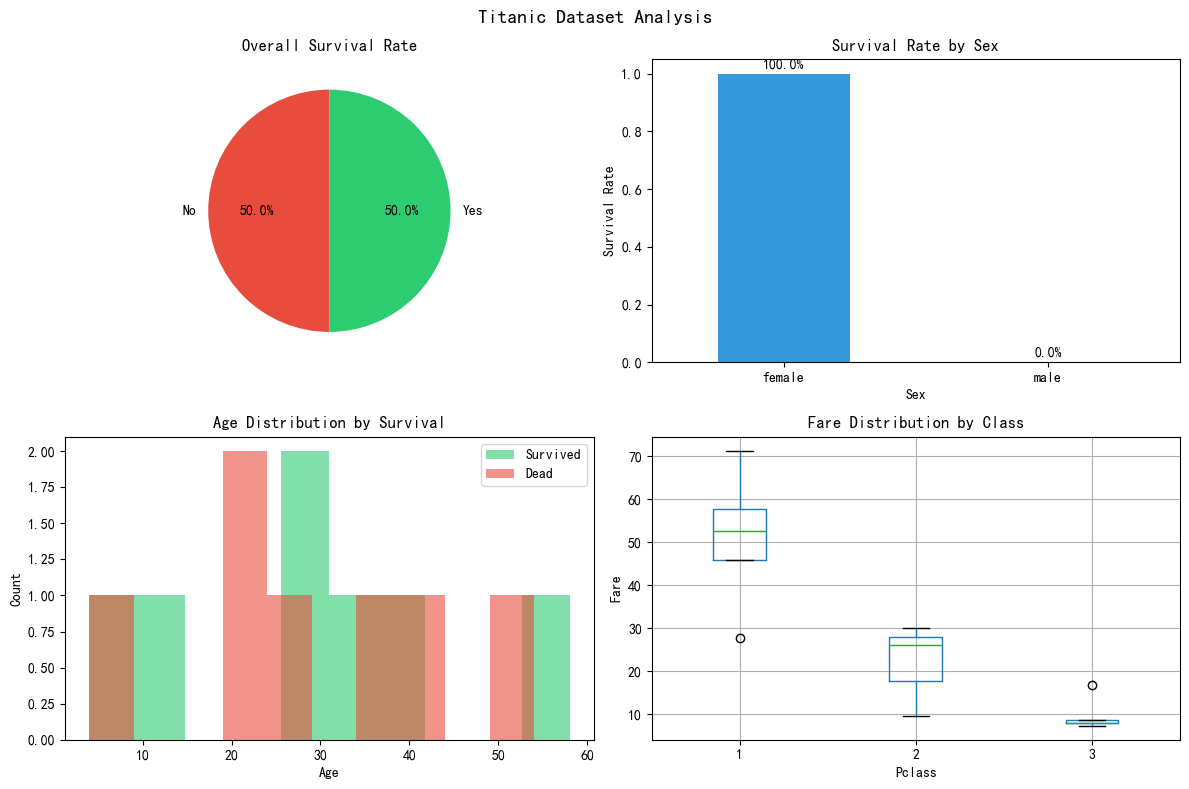

Figure saved as 10_2_titanic_analysis.png


In [17]:
# ===== 第4步：可视化 =====
import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"] = ["SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 子图1: 生存率饼图
ax1 = axes[0, 0]
surv_counts = df["Survived"].value_counts()
ax1.pie(surv_counts, labels=["No", "Yes"], autopct="%1.1f%%",
        colors=["#e74c3c", "#2ecc71"], startangle=90)
ax1.set_title("Overall Survival Rate")

# 子图2: 性别生存率柱状图
ax2 = axes[0, 1]
sex_surv = df.groupby("Sex")["Survived"].mean()
sex_surv.plot(kind="bar", ax=ax2, color=["#3498db", "#e91e63"])
ax2.set_title("Survival Rate by Sex")
ax2.set_ylabel("Survival Rate")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
for i, v in enumerate(sex_surv):
    ax2.text(i, v + 0.02, f"{v:.1%}", ha="center")

# 子图3: 年龄分布直方图
ax3 = axes[1, 0]
survived = df[df["Survived"] == 1]["Age"]
not_survived = df[df["Survived"] == 0]["Age"]
ax3.hist(survived, bins=10, alpha=0.6, label="Survived", color="#2ecc71")
ax3.hist(not_survived, bins=10, alpha=0.6, label="Dead", color="#e74c3c")
ax3.set_title("Age Distribution by Survival")
ax3.set_xlabel("Age")
ax3.set_ylabel("Count")
ax3.legend()

# 子图4: 船舱等级与票价箱线图
ax4 = axes[1, 1]
df.boxplot(column="Fare", by="Pclass", ax=ax4)
ax4.set_title("Fare Distribution by Class")
ax4.set_xlabel("Pclass")
ax4.set_ylabel("Fare")

plt.suptitle("Titanic Dataset Analysis", fontsize=14)
plt.tight_layout()
plt.savefig("10_2_titanic_analysis.png", dpi=100, bbox_inches="tight")
plt.show()
print("Figure saved as 10_2_titanic_analysis.png")


---
## 练习题

### 练习1：DataFrame 基本操作
创建一个包含 10 名学生信息的 DataFrame（姓名、语文、数学、英语成绩），然后：
1. 计算每个学生的总分和平均分
2. 找出数学成绩最高的学生
3. 筛选出所有科目都及格（>=60）的学生

### 练习2：数据融合
创建两个 DataFrame：
- `students`：学号、姓名、班级
- `scores`：学号、科目、成绩
使用 merge 将它们合并，并按学号和科目分组，计算每个学生的平均成绩。

### 练习3：缺失值处理
生成一个含随机缺失值的 DataFrame（5列x20行），分别用：
1. 均值填充数值列
2. 众数填充类别列
3. 删除超过 50% 缺失值的列

### 练习4：分组聚合
对 employee_data.csv 数据：
1. 按部门和城市双重分组，计算薪资统计量
2. 使用 transform 添加"部门薪资排名"列
3. 找出各部门薪资最高的人


In [18]:
# ===== 练习题参考答案 =====

# --- 练习1 ---
print("===== 练习1 =====")
np.random.seed(42)
students = pd.DataFrame({
    "姓名": [f"学生{i}" for i in range(1, 11)],
    "语文": np.random.randint(50, 100, 10),
    "数学": np.random.randint(50, 100, 10),
    "英语": np.random.randint(50, 100, 10)
})
students["总分"] = students["语文"] + students["数学"] + students["英语"]
students["平均分"] = students["总分"] / 3
print(students)

math_top = students.loc[students["数学"].idxmax(), "姓名"]
print(f"\n数学最高: {math_top}")

passed = students[(students["语文"] >= 60) & (students["数学"] >= 60) & (students["英语"] >= 60)]
print(f"全部及格的人数: {len(passed)}")

# --- 练习2 ---
print("\n===== 练习2 =====")
stu = pd.DataFrame({
    "学号": [1, 2, 3, 1, 2, 3],
    "姓名": ["张三", "李四", "王五", "张三", "李四", "王五"],
    "班级": ["A", "A", "B", "A", "A", "B"]
})
scores = pd.DataFrame({
    "学号": [1, 1, 2, 2, 3, 3],
    "科目": ["数学", "语文", "数学", "语文", "数学", "语文"],
    "成绩": [95, 88, 78, 92, 85, 90]
})
merged = pd.merge(stu, scores, on="学号")
avg = merged.groupby(["学号", "姓名"])["成绩"].mean().reset_index()
avg.columns = ["学号", "姓名", "平均成绩"]
print(avg)

# --- 练习3 ---
print("\n===== 练习3 =====")
df_miss = pd.DataFrame(np.random.rand(20, 5), columns=["A", "B", "C", "D", "E"])
mask = np.random.rand(*df_miss.shape) < 0.15
df_miss[mask] = np.nan
print("缺失值统计:")
print(df_miss.isna().sum())
# 填充
for col in df_miss.columns:
    if df_miss[col].isna().sum() > 0:
        df_miss[col] = df_miss[col].fillna(df_miss[col].mean())
print("\n填充后缺失值:", df_miss.isna().sum().sum())

# --- 练习4 ---
print("\n===== 练习4 =====")
df = pd.read_csv("employee_data.csv")
# 部门+城市双分组
print(df.groupby(["部门", "城市"])["薪资"].agg(["mean", "count", "std"]).round(1))
# 薪资排名
df["部门薪资排名"] = df.groupby("部门")["薪资"].rank(ascending=False, method="min").astype(int)
print(df[["姓名", "部门", "薪资", "部门薪资排名"]])
# 各部门薪资最高的人
idx = df.groupby("部门")["薪资"].idxmax()
print("\n各部门薪资最高:")
print(df.loc[idx, ["姓名", "部门", "薪资"]])


===== 练习1 =====
     姓名  语文  数学  英语   总分        平均分
0   学生1  88  60  79  227  75.666667
1   学生2  78  73  87  238  79.333333
2   学生3  64  85  51  200  66.666667
3   学生4  92  89  70  251  83.666667
4   学生5  57  73  82  212  70.666667
5   学生6  70  52  61  183  61.000000
6   学生7  88  71  71  230  76.666667
7   学生8  68  51  93  212  70.666667
8   学生9  72  73  74  219  73.000000
9  学生10  60  93  98  251  83.666667

数学最高: 学生10
全部及格的人数: 6

===== 练习2 =====
   学号  姓名  平均成绩
0   1  张三  91.5
1   2  李四  85.0
2   3  王五  87.5

===== 练习3 =====
缺失值统计:
A    2
B    2
C    1
D    0
E    3
dtype: int64

填充后缺失值: 0

===== 练习4 =====
           mean  count     std
部门  城市                        
市场部 上海  20000.0      1     NaN
    深圳  22000.0      1     NaN
技术部 北京  20000.0      2  7071.1
    广州  18000.0      1     NaN
    深圳  21000.0      1     NaN
设计部 上海  16000.0      1     NaN
    广州  19000.0      1     NaN
   姓名   部门     薪资  部门薪资排名
0  张三  技术部  15000       4
1  李四  市场部  20000       2
2  王五  技术部  18000       3
3

---
## 本节小结

| 知识点 | 核心API |
|--------|---------|
| 数据结构 | `Series`, `DataFrame` |
| 创建 | `DataFrame(dict)`, `read_csv()`, `read_excel()` |
| 概览 | `head()`, `tail()`, `info()`, `describe()`, `dtypes` |
| 查询 | `loc[]`, `iloc[]`, `query()`, 条件过滤 |
| 融合 | `merge()`, `concat()`, `join()` |
| 缺失值 | `isna()`, `fillna()`, `dropna()`, `interpolate()` |
| 分组聚合 | `groupby()`, `agg()`, `transform()` |

> **关键提示**：Pandas 的 `groupby + agg/transform` 组合是数据分析的核心利器，务必熟练掌握！在竞赛中，数据清洗和特征工程往往比模型选择更重要。
